<a href="https://colab.research.google.com/github/ab-152E08/Baeva_Analysis-of-Big-Data-in-Physics-/blob/Machine-Learning/ML_cifar_CNN_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Some data-handling functions to download/import.

# from https://github.com/yandexdataschool/mlhep2018/blob/master/day2-Tue/seminar-03-keras-cnn/seminar_tf_keras.ipynb
"""I load some cifar"""

import numpy as np
from sklearn.model_selection import train_test_split
import os, sys
if sys.version_info[0] == 2:
    from urllib import urlretrieve
    import cPickle as pickle

else:
    from urllib.request import urlretrieve
    import pickle

def unpickle(file):
    fo = open(file, 'rb')
    if sys.version_info[0] == 2:
        dict = pickle.load(fo)
    else:
        dict = pickle.load(fo,encoding='latin1')

    fo.close()
    return dict




def download_cifar10(path,
                     url='https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz',
                     tarname='cifar-10-python.tar.gz',):
    import tarfile
    if not os.path.exists(path):
        os.mkdir(path)



    urlretrieve(url, os.path.join(path,tarname))
    tfile = tarfile.open(os.path.join(path,tarname))
    tfile.extractall(path=path)


def load_cifar10(data_path=".",channels_last=False,test_size=0.2,random_state=1337):

    test_path = os.path.join(data_path,"cifar-10-batches-py/test_batch")
    train_paths = [os.path.join(data_path,"cifar-10-batches-py/data_batch_%i"%i) for i in range(1,6)]

    if not os.path.exists(test_path) or not all(list(map(os.path.exists, train_paths))):
        print ("Dataset not found. Downloading...")
        download_cifar10(data_path)

    train_batches = list(map(unpickle,train_paths))
    test_batch = unpickle(test_path)

    X = np.concatenate([batch["data"] for batch in train_batches]).reshape([-1,3,32,32]).astype('float32')/255
    y = np.concatenate([batch["labels"] for batch in train_batches]).astype('int32')
    X_train,X_val,y_train,y_val = train_test_split(X,y,
                                                   test_size=test_size,
                                                   random_state=random_state)

    X_test = test_batch["data"].reshape([-1,3,32,32]).astype('float32')/255
    y_test = np.array(test_batch["labels"]).astype('int32')

    if channels_last:
        #convert from [batch,3,H,W] to [batch,H,W,3]
        #WARNING! Make this is only necessary for tensorflow-style dim order
        #If you use theano-style dimensions in keras config, skip this cell
        X_train = X_train.transpose([0,2,3,1])
        X_val   = X_val.transpose([0,2,3,1])
        X_test  = X_test.transpose([0,2,3,1])


    return X_train,y_train,X_val,y_val,X_test,y_test

In [2]:
import tensorflow as tf
#gpu_options = tf.GPUOptions(allow_growth=True, per_process_gpu_memory_fraction=0.1) # restricts GPU load for multi-user nodes

import tensorflow.keras as keras
from keras import backend as K
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
print(tf.__version__)
print(keras.__version__)

2.19.0
3.10.0


In [3]:
# Load the data samples

x_train,y_train,x_val,y_val,x_test,y_test = load_cifar10("cifar_data",channels_last=True)

NUM_CLASSES = 10
cifar10_classes = ["airplane", "automobile", "bird", "cat", "deer",
                   "dog", "frog", "horse", "ship", "truck"]

print("Train samples:", x_train.shape, y_train.shape)
print("Test samples:", x_test.shape, y_test.shape)
print("Val samples:", x_val.shape, y_val.shape)

Dataset not found. Downloading...


/tmp/ipykernel_569/3806609017.py:41: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tfile.extractall(path=path)


Train samples: (40000, 32, 32, 3) (40000,)
Test samples: (10000, 32, 32, 3) (10000,)
Val samples: (10000, 32, 32, 3) (10000,)


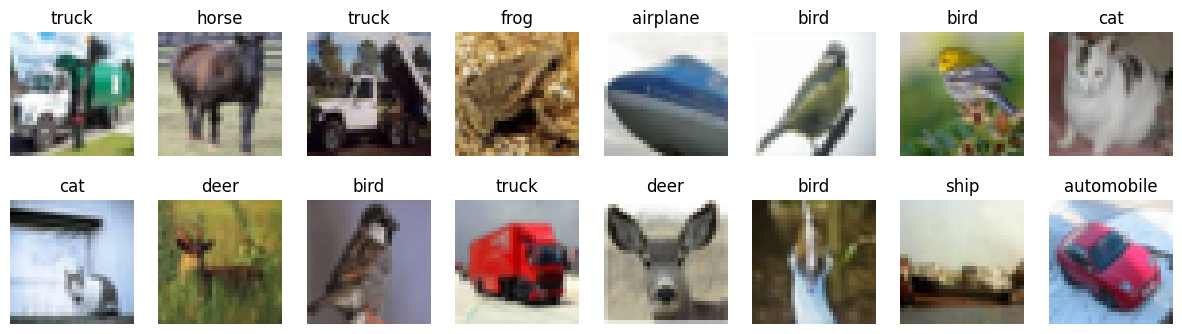

In [4]:
# show some random images from train, and their labels

cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 2.5 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_train))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_train[random_index, :])
        ax.set_title(cifar10_classes[y_train[random_index]])
plt.show()

"CIFAR-10 dataset contains 32x32 color images from 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck"

In [5]:
# normalize inputs
# convert class labels to one-hot encoded, should have shape (?, NUM_CLASSES)
# x_train = x_train.astype(np.float64) - 0.5

y_train = keras.utils.to_categorical(y_train, num_classes=10)

y_val = keras.utils.to_categorical(y_val, num_classes=10)

y_test = keras.utils.to_categorical(y_test, num_classes=10)

In [6]:
# import necessary building blocks
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout
from keras.layers import LeakyReLU

We do convolution -> pooling -> convolution -> pooling, flatten the shapes (?) and connect to the categories
One-hot encoding is convertion from categorical to binary -- is category is a separate column. 1 -- presence of the category, 0 -- absence

First try: 10 filters, activation in the dense layer softmax, and rate 0.1.
I realised that, when I use keras.layers.___, it does not work with the next cell, and produces this error:
Arguments `target` and `output` must have the same rank (ndim). Received: target.shape=(None, 10), output.shape=(None, 32, 32, 3)
So the next step was to add model.add() for each of the layers.

With that, I input the values
INIT_LR = 5e-3  (I was not sure how this part works, so I kept it the same)
BATCH_SIZE = 120
EPOCHS = 5
into the next cell, and got the next result:
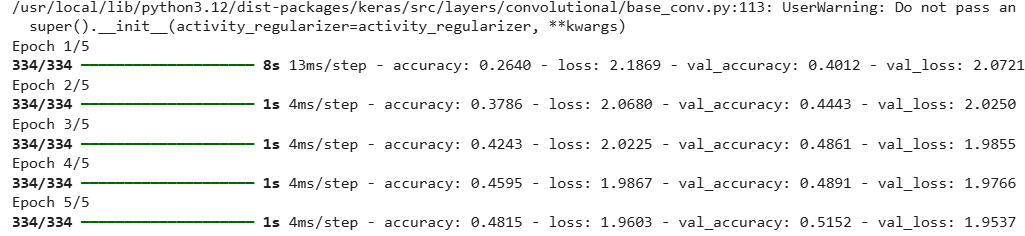


The accuracy was still quite low, so I needed to raise the rate at which it was increasing, and, maybe, add a few more epochs, which was my next step.
Each new group of runs, I was changing only one of the initial values, in order to see how each of them individually affects the result. (I probably could have just googled it, but it seemed more interesting that way)

Changing rate (first bunch of changes, batch size at 100 and 5 epochs):
1) 10e-3 accuracy got to 0.5, first jumped for 0.26 to 0.41, and then was stuck there for a bit, getting to the end value

2) 14e-3 got to 0.45, almost no difference between epochs from 2 to 5

3) 5e-2 accuracy stayed at pretty much the same value (around 0.26) for all 5 epochs, which seems weird.

4) 1e-3 accuracy got to 0.39, with small changes between epoch 2-5 again.

This way I tested which batch size would be the best (testing from 80 to 220), and epoch sizes.

Results between 5 epochs and 10 epochs did not vary much, ending up around 0.5 - 0.51 on good runs, so I kept it at 5 (at least for now), for computational efficiency

The process before did not give great results -- the maximum accuracy I could get was 0.51, and the final results had a few mistakes and low accuracies.

First, I decided to see what will happen if I add another loop of Conv2D->MaxPooling2D, and increase the amount of epochs to 20. That did not change the results significantly --  the accuracy was still 0.51.

So I decided to try and make my model more complex. Adding the hidden layer that we used in the first exercise (tutor suggestion)
(model.add(Dense(units=32, activation='sigmoid')))
did improve the results. In 5 epochs in reached 0.44 and in 30 it reached 0.58 -- so the problem of getting stuck early on in the same value was almost solved, and the accuracy increased.


However, the learning curve was still weird and too small, so I decided to plot training accuracy and training loss in order to visualize it.
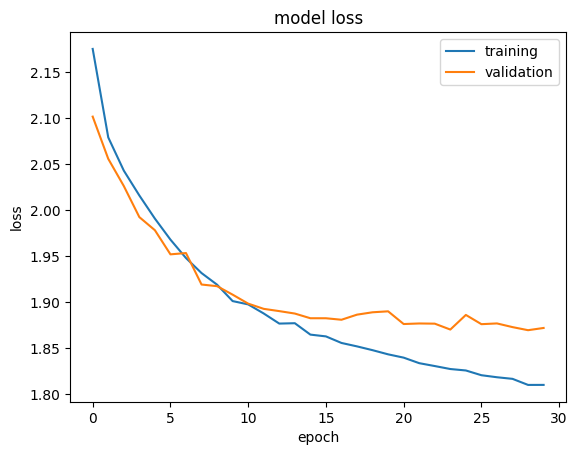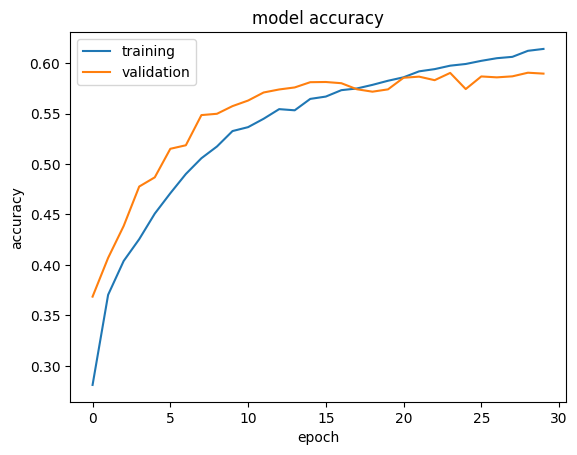

The first 5-10 epochs go approximately the way they are supposed to, but then the lines cross and diverge. That means that the model is getting overtrained, so I lowered the amount of epoch to the amount when it the two lines cross -- 10 epochs.

After looking into the documentation, I decided to switch activation for the dense layer from softmax to sigmoid. According to the documentation (https://keras.io/api/layers/activations/), sigmoid is equivalent to a 2-element softmax, but with an increased accuracy (went to 0.8), the validation accuracy decreased.

As I learned, softmax produced the proper probability distribution across all classes, and sigmoid produces independent probabilities for each class. So my model was, probably, just confidently incorrect, becuase with only sigmoid and no softmax it was not considering other classes.

As an experiment, I tried

    model.add(Dense(units=100, activation='relu'))
    model.add(Dropout(rate = 0.1, noise_shape=None, seed=None))
    model.add(Dense(units = 10, activation = "softmax"))

which gave me this: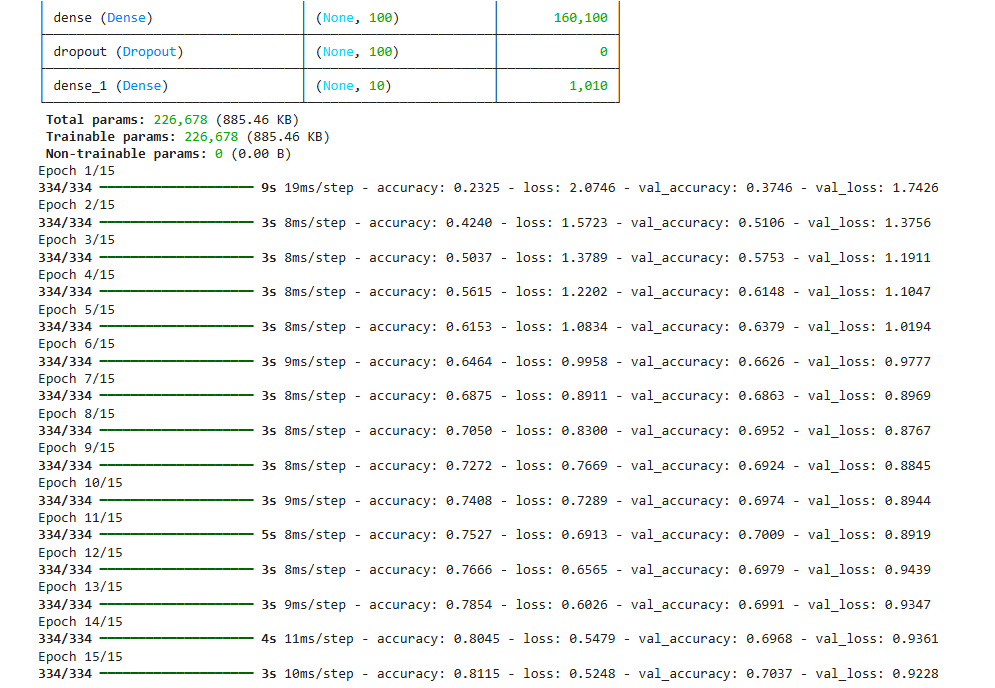

With model loss and accuracy as follows:

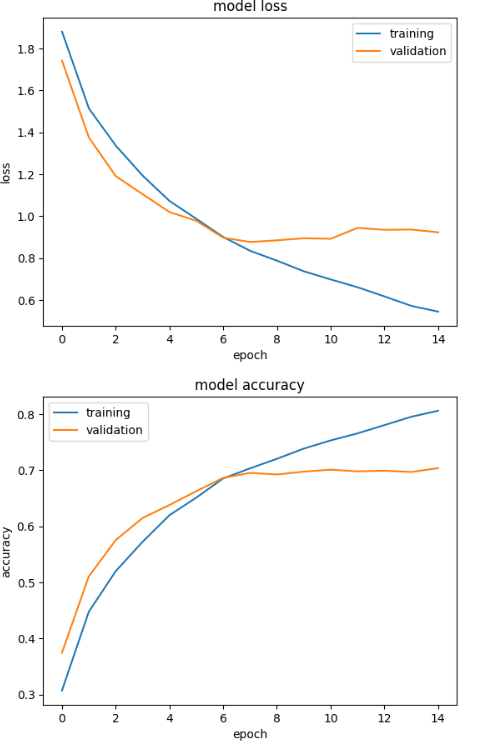

Which once again indicates overfitting, but the result at the moment when the graph crosses (0.7 accuracy) was still better than what I had before.

Then a better result (with the same accuracy as before, at 0,7, but much less overfitting) was reached when I increased dropout rate from 0.1 to 0.25, and increased units for Dense from 100 to 512. It produces the following graphs:

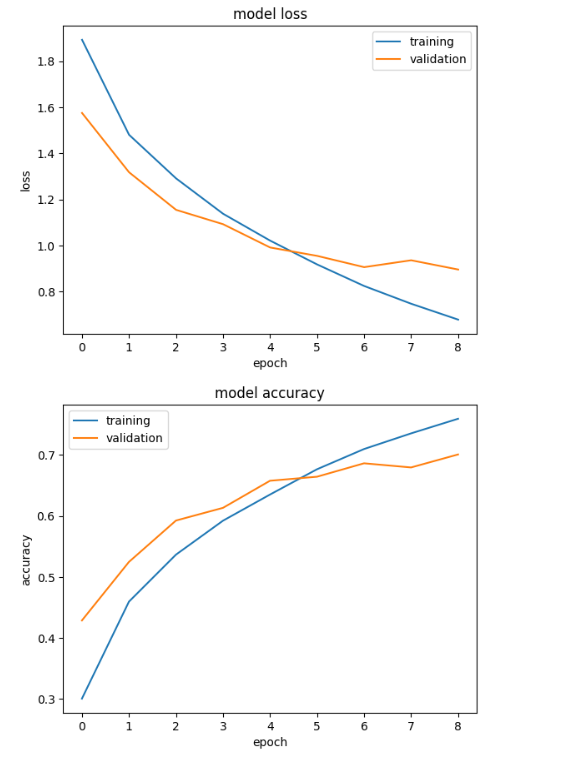

After that, by recommendation of the tutor, I added Batch Normalization after every convolutional layer, because it stabilizes the output distribution before pooling discards spatial info. I also added another two convolutional layers with 128 filters. Spatial size is now 4×4, filters double again following the same logic as before, with 32 to 64 -- there are fewer spatial positions, therefore more abstract concepts to distinguish.

With that, I found that adding two convolutional layers in a row in each blocks helps with accuracy -- the first one detects simple edges and colors, and the second one combines those into small textures. So it learns more features before the pooling (spatial compression).

Together with this, I added dropout after each pooling, increasing from 0.25 the firs time to 0.5 on the subsequent times. Since the later layers already have more information stored (learned), it has more tendency for overfitting and needs a stronger regularization.

Finally, I was able to add more epochs (increasing to 20) without worrying about overfitting -- the new model was be more consistent and had more pecautions against overfitting.

Iy have me validation accuracy of 0.75, which was even higher than the training accuracy.

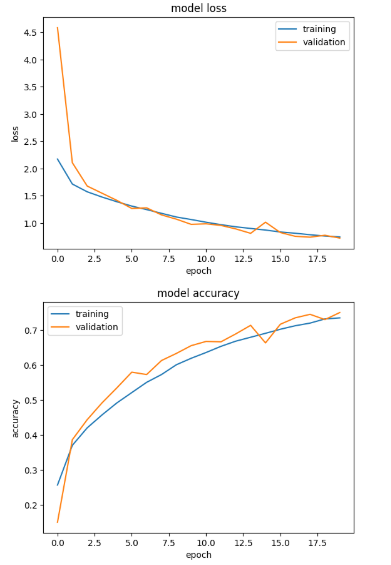

With that success, I have heightened the number of epochs even more -- to 30 -- and the validation accuracy reached 0.79, which I considered a good result. It did display slight overfitting (with the training accuracy reaching 0.8), but it was mentioned at the practical that a small amount of overfitting is not usually a problem, as long as there was no big gap between validation and training accuracies.

Overall, the accuracy inproved immensely from the start of my work on this model -- it grew more complex, and almost never thinks that a horse is an airplan anymore.


The confusion matrix went from this:


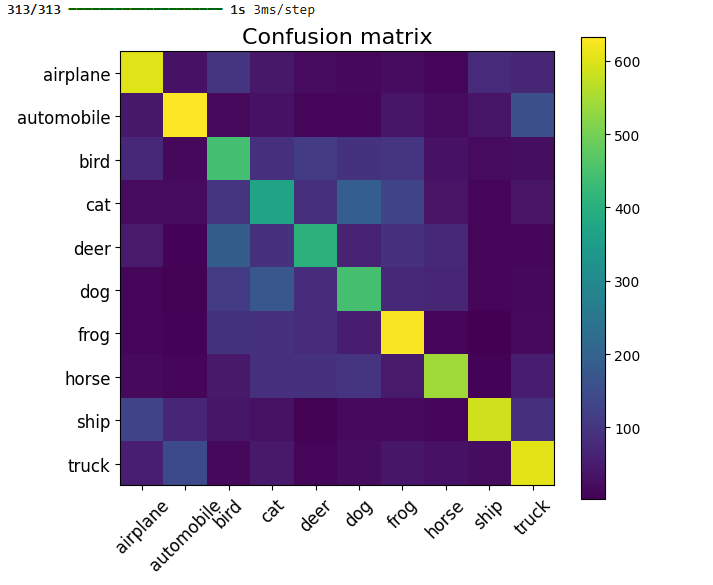


To this:


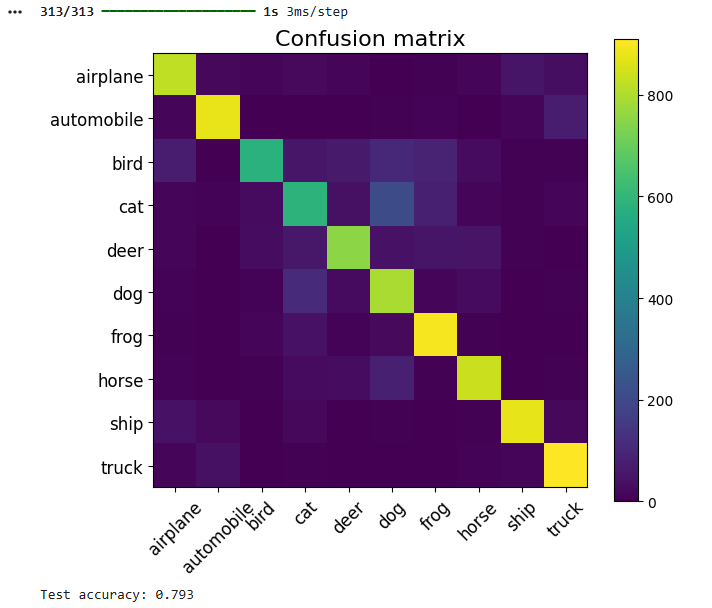

In [24]:
from tensorflow.keras.layers import BatchNormalization
def make_model():
    """
    Define your model architecture here.
    Returns `Sequential` model.
    """

    model = Sequential()
    model.add(Conv2D(filters = 32, kernel_size = 3, padding = 'same', activation ='relu', strides = (1,1), input_shape = (32,32,3)))
    #padding 'same'  keeps the feature map the same spatial size after each conv, so no information is lost at the borders
    model.add(Conv2D(filters=32, kernel_size=3, padding = 'same', activation='relu'))
    model.add(BatchNormalization())
    #^Produces a tensor of outputs
    model.add(MaxPooling2D(pool_size=(2, 2), strides=None))
    model.add(Dropout(0.25))


    model.add(Conv2D(filters = 64, kernel_size = (3,3), padding = 'same', activation ='relu', strides = (1,1)))
    model.add(Conv2D(filters=64, kernel_size=3, padding = 'same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=None))
    model.add(Dropout(0.5))

    model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = 'same', activation ='relu', strides = (1,1)))
    model.add(Conv2D(filters=128, kernel_size=3, padding = 'same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=None))
    model.add(Dropout(0.5))


    model.add(Flatten())
    model.add(Dense(units=512, activation='relu'))
    model.add(Dropout(rate = 0.25, noise_shape=None, seed=None))
    model.add(Dense(units = 10, activation = "softmax"))
    #Using softmax because it's the one used in the end
    #10 because 10 categories
    #model.add(Dropout(rate = 0.1, noise_shape=None, seed=None))



    # Ensure normalized probabilities over the 10 classes
    #model.add(Activation("softmax"))

    return model



Add normalisation?


    ### STUDENT CODE HERE ###
    ### --> Build your convolutional neural network.
    ### First, make a CNN layer with some small kernels to learn some basic features, with Conv2D.

   
    
    ### Then, add a Pooling layer to pick up the relevant kernels.

    
    ### Then, Flatten it and add some fully-connected (Dense) normal NN layers,
    ###  to learn the relevant combinations of low-level kernel features.
    
    
  
    ### Finally, some regularisation is advised, using a Dropout layer, to avoid local minima.
    ### Make sure the output is of the same shape as the number of labels we have,
    ### And the input is the same as the figures (which now have a 3rd dimension - color!)
    ### Again, use google to find information on these classes.

    


    ### END STUDENT CODE ###


In [15]:
### STUDENT CODE HERE ###
### --> change the parameters below to perform a better training

INIT_LR = 5e-4  # initial learning rate
BATCH_SIZE = 120
EPOCHS = 30


K.clear_session()  # clear default graph
# don't call K.set_learning_phase() !!! (otherwise will enable dropout in train/test simultaneously)
model = make_model()  # define our model
model.summary()
# prepare model for fitting (loss, optimizer, etc)
model.compile(
    loss='categorical_crossentropy',  # we train 10-way classification
    optimizer=keras.optimizers.Adamax(learning_rate=INIT_LR),  # for SGD.
    metrics=['accuracy']  # report accuracy during training
)

# fit model
history = model.fit(
    x_train, y_train,  # prepared data
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    shuffle=True,
)

# save weights to file to avoid re-training
model.save_weights("myweights.weights.h5")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,342,122 (5.12 MB)

 Trainable params: 1,341,674 (5.12 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 21s 37ms/step - accuracy: 0.2233 - loss: 2.6024 - val_accuracy: 0.1965 - val_loss: 4.3412
Epoch 2/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.3596 - loss: 1.7472 - val_accuracy: 0.3950 - val_loss: 2.3110
Epoch 3/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.4231 - loss: 1.5716 - val_accuracy: 0.4519 - val_loss: 2.0556
Epoch 4/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.4663 - loss: 1.4590 - val_accuracy: 0.5184 - val_loss: 1.5139
Epoch 5/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5019 - loss: 1.3645 - val_accuracy: 0.5175 - val_loss: 1.6271
Epoch 6/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.5317 - loss: 1.2897 - val_accuracy: 0.5916 - val_loss: 1.2487
Epoch 7/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5719 - loss: 1.1903 - val_accuracy: 0.6351 - val_loss: 1.0514
Epoch 8/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5991 - loss: 1.1171 - val_acc

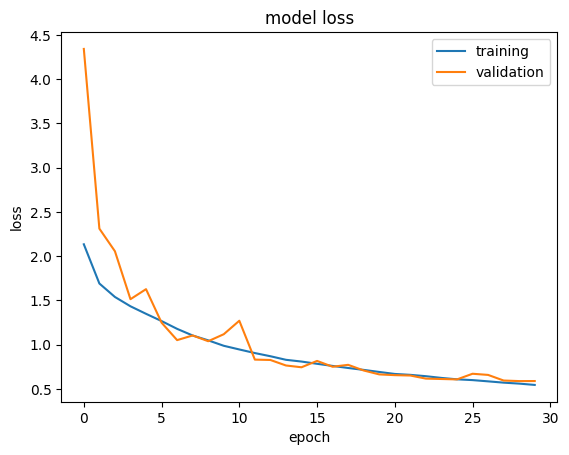

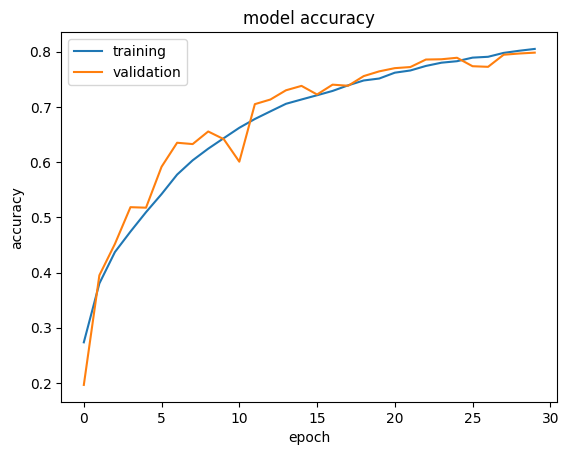

In [16]:
# Plot the progression of the training loss

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['training', 'validation'], loc='best')
plt.show()


plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['training', 'validation'], loc='best')
plt.show()

In [19]:
# load weights from file (can call without model.fit)
model.load_weights("myweights.weights.h5")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


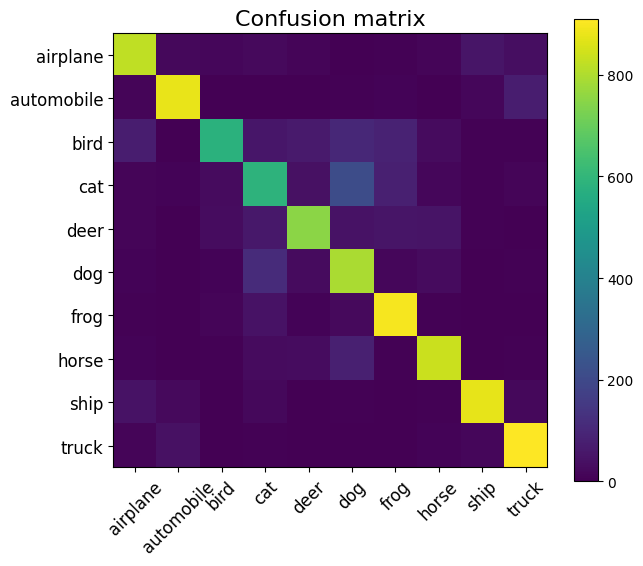

Test accuracy: 0.793


In [20]:
# make test predictions
y_pred_test = model.predict(x_test)
y_pred_test_classes = np.argmax(y_pred_test, axis=1)
y_pred_test_max_probas = np.max(y_pred_test, axis=1)
y_test_index = [list(onehot).index(1) for onehot in y_test]

# confusion matrix and accuracy
from sklearn.metrics import confusion_matrix, accuracy_score
plt.figure(figsize=(7, 6))
plt.title('Confusion matrix', fontsize=16)
plt.imshow(confusion_matrix(y_test_index, y_pred_test_classes))
plt.xticks(np.arange(10), cifar10_classes, rotation=45, fontsize=12)
plt.yticks(np.arange(10), cifar10_classes, fontsize=12)
plt.colorbar()
plt.show()
print("Test accuracy:", accuracy_score(y_test_index, y_pred_test_classes))

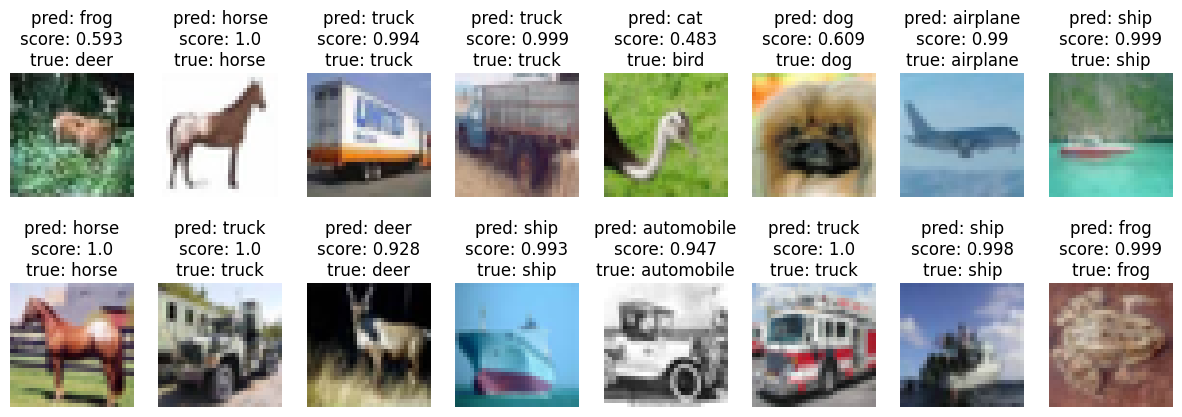

In [23]:
# inspect preditions
cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 3 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_test))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_test[random_index, :])
        pred_label = cifar10_classes[y_pred_test_classes[random_index]]
        pred_proba = y_pred_test_max_probas[random_index]
        true_label = cifar10_classes[y_test_index[random_index]]
        ax.set_title("pred: {}\nscore: {:.3}\ntrue: {}".format(
               pred_label, pred_proba, true_label
        ))
plt.show()

I do agree with the model on some of those -- this is NOT a cat:

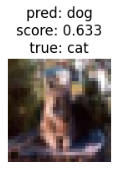

# Some tips on how to improve:

* The ultimate quest is to create a network that has as high __accuracy__ as you can push it.

## Potential grading:
* starting at zero points
* +2 for describing your iteration path in a report below.
* +2 for building a network that gets above 20% accuracy
* +1 for beating each of these milestones on __TEST__ dataset:
    * 50% (5 total)
    * 60% (6 total)
    * 65% (7 total)
    * 70% (8 total)
    * 75% (9 total)
    * 80% (10 total)

## Bonus points
Common ways to get bonus points are:
* Get higher score, obviously.
* Anything special about your NN. For example \"A super-small/fast NN that gets 80%\" gets a bonus.
* Any detailed analysis of the results. (saliency maps, whatever)


## Tips on what can be done:

 * __Network size__
   * More neurons,
   * More layers, ([lasagne docs](http://lasagne.readthedocs.org))
   * Nonlinearities in the hidden layers
   * tanh, relu, leaky relu, etc
   * Larger networks may take more epochs to train, so don't discard your net just because it could didn't beat the baseline in 5 epochs.

 * __Convolution layers__
   * they __are a must__ unless you have any super-ideas
   * `network = lasagne.layers.Conv2DLayer(prev_layer,`
     `                       num_filters = n_neurons,`
     `                       filter_size = (filter width, filter height),`
     `                       nonlinearity = some_nonlinearity)`
   * Warning! Training convolutional networks can take long without GPU. That's okay.
     * If you are CPU-only, we still recomment to try a simple convolutional architecture
     * a perfect option is if you can set it up to run at nighttime and check it up at the morning.
     * Make reasonable layer size estimates. A 128-neuron first convolution is likely an overkill.
     * __To reduce computation__ time by a factor in exchange for some accuracy drop, try using __stride__ parameter. A stride=2 convolution should take roughly 1/4 of the default (stride=1) one.

   * Plenty other layers and architectures
     * http://lasagne.readthedocs.org/en/latest/modules/layers.html
     * batch normalization, pooling, etc


 * __Early Stopping__
   * Training for 100 epochs regardless of anything is probably a bad idea.
   * Some networks converge over 5 epochs, others - over 500.
   * Way to go: stop when validation score is 10 iterations past maximum


 * __Faster optimization__ -
   * rmsprop, nesterov_momentum, adam, adagrad and so on.
     * Converge faster and sometimes reach better optima
     * It might make sense to tweak learning rate/momentum, other learning parameters, batch size and number of epochs
   * __BatchNormalization__ (lasagne.layers.batch_norm) FTW!


 * __Regularize__ to prevent overfitting
   * Add some L2 weight norm to the loss function, theano will do the rest
     * Can be done manually or via - http://lasagne.readthedocs.org/en/latest/modules/regularization.html
   * Dropout - to prevent overfitting
     * `lasagne.layers.DropoutLayer(prev_layer, p=probability_to_zero_out)`   
     * Don't overdo it. Check if it actually makes your network better


 * __Data augmentation__ - getting 5x as large dataset for free is a great deal
   * Zoom-in+slice = move
   * Rotate+zoom(to remove black stripes)
   * any other perturbations
   * Add Noize (easiest: GaussianNoizeLayer)
   * Simple way to do that (if you have PIL/Image):
     * ```from scipy.misc import imrotate,imresize```
     * and a few slicing
   * Stay realistic. There's usually no point in flipping dogs upside down as that is not the way you usually see them.


